# HDB Resale Price Regression — Notebook 8: Lease Decay Awareness Over Time

**Research question:** How has the market's pricing of remaining lease changed over time? This is to follow up on a very old story of mine: https://www.channelnewsasia.com/singapore/big-read-no-easy-answers-hdb-lease-decay-issue-public-mindset-has-change-first-5731701

We run the same regression specification across non-overlapping 2-year windows from 1990 to 2025, tracking how the coefficient on `remaining_lease_years` evolves. If lease decay awareness has grown — particularly after PM Lee's 2017 National Day Rally speech warning that old HDB flats will eventually become worthless — we should see the marginal effect of remaining lease increase over time.

**Key policy events to watch for:**
- **1997:** Asian Financial Crisis — price crash, market structure change
- **2013:** Total Debt Servicing Ratio (TDSR) — restructured HDB financing
- **2017:** PM Lee's NDR speech on lease decay — explicit government messaging that 99-year leases mean flat value eventually goes to zero
- **2020:** COVID-19 — market disruption, then price surge
- **2022:** Further cooling measures (15-month wait-out period)

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('Setup complete.')

Setup complete.


## Methodology

**Model specification:** Same controls as Model 10 (Notebook 6), minus geography and superstition variables which require geocoding not available for the full historical dataset:

```
resale_price ~ town + flat_type + floor_area_sqm + storey_mid + 
               remaining_lease_years + remaining_lease_sq + 
               flat_model + month_FE
```

Town fixed effects absorb most geographic variation. The key output is the **cost of losing one year of remaining lease** at 70 years (close to the historical median), computed as:

> cost of −1 year = −(β₁ + 2 × β₂ × 70)

where β₁ is the linear lease coefficient and β₂ is the quadratic term. We negate the marginal effect so that a positive value means "losing a year costs you $X." We normalise by each period's mean price to make the effect comparable across eras of vastly different price levels.

**Caveat on lease variation:** In the 1990s, most flats had 70–95 years of remaining lease — limited variation makes the coefficient harder to estimate precisely. By the 2020s, remaining leases range from ~40 to ~99 years, allowing sharper estimation. A growing coefficient could partly reflect more variation in the data, not just changed buyer behaviour. But a structural break around a specific policy event (2017) would still indicate a genuine shift in market pricing.

In [2]:
# Load full dataset
full = pd.read_csv('data/hdb_resale_full.csv', low_memory=False)
full['month'] = pd.to_datetime(full['month'])
full['year'] = full['month'].dt.year
full['remaining_lease_sq'] = full['remaining_lease_years'] ** 2
full['month_str'] = full['month'].dt.strftime('%Y-%m')

print(f'Full dataset: {len(full):,} rows')
print(f'Date range: {full["month"].min().strftime("%Y-%m")} to {full["month"].max().strftime("%Y-%m")}')
print(f'Remaining lease range: {full["remaining_lease_years"].min():.0f} to {full["remaining_lease_years"].max():.0f} years')

# Define non-overlapping 2-year windows
windows = []
for start in range(1990, 2026, 2):
    end = start + 1
    label = f'{start}-{str(end)[-2:]}'
    windows.append((start, end, label))

print(f'\n{len(windows)} windows: {windows[0][2]} to {windows[-1][2]}')

Full dataset: 975,231 rows
Date range: 1990-01 to 2026-04
Remaining lease range: 39 to 101 years

18 windows: 1990-91 to 2024-25


## Run regressions across all periods

In [3]:
formula = ('resale_price ~ C(town) + C(flat_type) + floor_area_sqm + storey_mid + '
           'remaining_lease_years + remaining_lease_sq + C(flat_model_grouped) + C(month_str)')

results = []
for start, end, label in windows:
    w = full[(full['year'] >= start) & (full['year'] <= end)].copy()
    
    if len(w) < 500:
        print(f'{label}: only {len(w)} rows, skipped')
        continue
    
    # Group rare flat models within this window
    mc = w['flat_model'].value_counts()
    rare = mc[mc < 50].index
    w['flat_model_grouped'] = w['flat_model'].apply(lambda x: 'Other' if x in rare else x)
    
    try:
        model = smf.ols(formula, data=w).fit(cov_type='HC1')
        
        coef_linear = model.params['remaining_lease_years']
        coef_quad = model.params['remaining_lease_sq']
        
        # Marginal effect at 70 years: dY/dL = beta1 + 2*beta2*L
        # Negate to get COST of losing 1 year (positive = costs more)
        marginal_70 = -(coef_linear + 2 * coef_quad * 70)
        
        # SE of marginal effect via delta method (SE is symmetric, no sign flip needed)
        cov_mat = model.cov_params()
        var_marginal = (cov_mat.loc['remaining_lease_years', 'remaining_lease_years'] +
                       (2*70)**2 * cov_mat.loc['remaining_lease_sq', 'remaining_lease_sq'] +
                       2 * (2*70) * cov_mat.loc['remaining_lease_years', 'remaining_lease_sq'])
        se_marginal = np.sqrt(max(var_marginal, 0))
        
        mean_price = w['resale_price'].mean()
        
        results.append({
            'period': label,
            'midpoint': (start + end) / 2,
            'n': len(w),
            'mean_price': mean_price,
            'mean_lease': w['remaining_lease_years'].mean(),
            'lease_sd': w['remaining_lease_years'].std(),
            'r_squared': model.rsquared,
            'coef_lease': coef_linear,
            'p_lease': model.pvalues['remaining_lease_years'],
            'coef_lease_sq': coef_quad,
            'p_lease_sq': model.pvalues['remaining_lease_sq'],
            'cost_per_year': marginal_70,
            'se_marginal': se_marginal,
            'cost_pct': (marginal_70 / mean_price) * 100,
            'se_pct': (se_marginal / mean_price) * 100,
        })
        
        sig_l = '*' if model.pvalues['remaining_lease_years'] < 0.05 else ' '
        sig_q = '*' if model.pvalues['remaining_lease_sq'] < 0.05 else ' '
        print(f'{label}:  n={len(w):>6,}  R²={model.rsquared:.3f}  '
              f'lease={coef_linear:>+9,.0f}{sig_l}  lease²={coef_quad:>+7.1f}{sig_q}  '
              f'cost of -1yr @70={marginal_70:>8,.0f}  ({marginal_70/mean_price*100:.2f}% of mean)')
    except Exception as e:
        print(f'{label}: FAILED — {e}')

res = pd.DataFrame(results)
print(f'\nCompleted {len(res)} regressions.')

1990-91:  n=25,360  R²=0.917  lease=      -76   lease²=   +4.9   cost of -1yr @70=    -609  (-0.86% of mean)


1992-93:  n=32,619  R²=0.898  lease=   +1,760   lease²=   -4.2   cost of -1yr @70=  -1,165  (-1.05% of mean)


1994-95:  n=53,662  R²=0.949  lease=   +1,047   lease²=   -1.0   cost of -1yr @70=    -901  (-0.47% of mean)


1996-97:  n=66,678  R²=0.960  lease=   -8,887*  lease²=  +60.2*  cost of -1yr @70=     453  (0.15% of mean)


1998-99:  n=108,877  R²=0.962  lease=   -3,454*  lease²=  +29.1*  cost of -1yr @70=    -621  (-0.24% of mean)


...

2016-17:  n=39,882  R²=0.866  lease=     -435   lease²=  +28.9*  cost of -1yr @70=  -3,604  (-0.82% of mean)


2018-19:  n=43,747  R²=0.865  lease=   +7,057*  lease²=  -15.0*  cost of -1yr @70=  -4,952  (-1.13% of mean)


2020-21:  n=52,420  R²=0.882  lease=   +4,380*  lease²=   +4.7*  cost of -1yr @70=  -5,036  (-1.04% of mean)


2022-23:  n=52,474  R²=0.888  lease=   +5,346*  lease²=   +0.1   cost of -1yr @70=  -5,361  (-0.96% of mean)


2024-25:  n=52,918  R²=0.883  lease=  +11,674*  lease²=  -37.4*  cost of -1yr @70=  -6,434  (-1.02% of mean)

Completed 18 regressions.


## Results table

In [4]:
display_df = res[['period', 'n', 'mean_price', 'r_squared',
                   'coef_lease', 'coef_lease_sq',
                   'cost_per_year', 'cost_pct',
                   'mean_lease', 'lease_sd']].copy()

display_df.columns = ['Period', 'N', 'Mean Price', 'R²',
                       'β lease', 'β lease²',
                       'Cost of −1yr @70', 'Cost %',
                       'Mean Lease', 'SD Lease']

# Format for display
fmt = display_df.copy()
fmt['N'] = fmt['N'].apply(lambda x: f'{x:,}')
fmt['Mean Price'] = fmt['Mean Price'].apply(lambda x: f'${x:,.0f}')
fmt['R²'] = fmt['R²'].apply(lambda x: f'{x:.3f}')
fmt['β lease'] = fmt['β lease'].apply(lambda x: f'${x:+,.0f}')
fmt['β lease²'] = fmt['β lease²'].apply(lambda x: f'{x:+.1f}')
fmt['Cost of −1yr @70'] = fmt['Cost of −1yr @70'].apply(lambda x: f'${x:,.0f}')
fmt['Cost %'] = fmt['Cost %'].apply(lambda x: f'{x:.2f}%')
fmt['Mean Lease'] = fmt['Mean Lease'].apply(lambda x: f'{x:.0f} yr')
fmt['SD Lease'] = fmt['SD Lease'].apply(lambda x: f'{x:.1f} yr')

print(fmt.to_string(index=False))

 Period       N Mean Price    R²  β lease β lease² Cost of −1yr @70 Cost % Mean Lease SD Lease
1990-91  25,360    $70,876 0.917     $-76     +4.9            $-609 -0.86%      88 yr   4.9 yr
1992-93  32,619   $111,273 0.898  $+1,760     -4.2          $-1,165 -1.05%      88 yr   5.3 yr
1994-95  53,662   $192,708 0.949  $+1,047     -1.0            $-901 -0.47%      87 yr   5.4 yr
1996-97  66,678   $293,063 0.960  $-8,887    +60.2             $453  0.15%      86 yr   5.8 yr
1998-99 108,877   $254,806 0.962  $-3,454    +29.1            $-621 -0.24%      85 yr   6.5 yr
2000-01  72,917   $250,444 0.948  $-4,411    +38.6            $-994 -0.40%      85 yr   7.7 yr
2002-03  65,101   $233,279 0.928  $-8,262    +62.7            $-520 -0.22%      84 yr   8.4 yr
2004-05  59,157   $234,659 0.869  $-9,057    +68.2            $-485 -0.21%      82 yr   9.1 yr
2006-07  54,409   $249,071 0.871  $-7,065    +59.7          $-1,297 -0.52%      81 yr   9.6 yr
2008-09  57,744   $328,107 0.862  $-5,216    +50.4

## Chart: cost of losing one year of lease over time

/var/folders/7h/fxll2jhj3s9dl0hn4k_ff6v00000gn/T/ipykernel_58593/3679481374.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


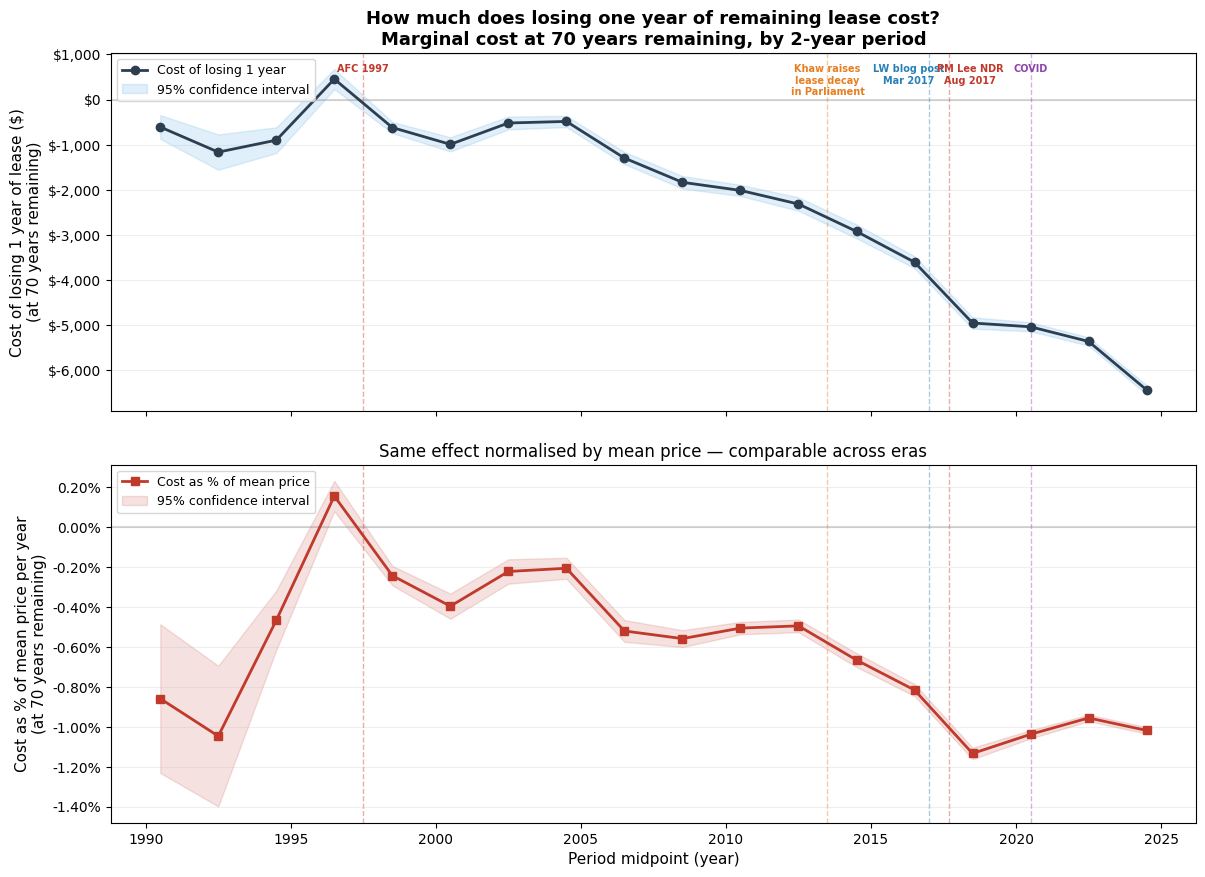

Saved to data/lease_decay_over_time.png


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'hspace': 0.15})

# Policy events to annotate
events = [
    (1997.5, 'AFC 1997', '#c0392b'),
    (2013.5, 'Khaw raises\nlease decay\nin Parliament', '#e67e22'),
    (2017.0, "LW blog post\nMar 2017", '#2980b9'),
    (2017.7, "PM Lee NDR\nAug 2017", '#c0392b'),
    (2020.5, 'COVID', '#8e44ad'),
]

# --- Panel 1: Raw dollars ---
line1, = ax1.plot(res['midpoint'], res['cost_per_year'], 'o-', color='#2c3e50',
         linewidth=2, markersize=6, zorder=3, label='Cost of losing 1 year')
band1 = ax1.fill_between(res['midpoint'],
                  res['cost_per_year'] - 1.96 * res['se_marginal'],
                  res['cost_per_year'] + 1.96 * res['se_marginal'],
                  alpha=0.15, color='#3498db', label='95% confidence interval')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.set_ylabel('Cost of losing 1 year of lease ($)\n(at 70 years remaining)', fontsize=11)
ax1.set_title('How much does losing one year of remaining lease cost?\n'
              'Marginal cost at 70 years remaining, by 2-year period',
              fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.grid(axis='y', alpha=0.2)
ax1.legend(loc='upper left', fontsize=9)

for year, label, color in events:
    for ax in [ax1, ax2]:
        ax.axvline(x=year, color=color, linestyle='--', alpha=0.4, linewidth=1)

# Annotate on panel 1 — stagger to avoid overlap
anno_offsets = {
    'AFC 1997': (0, -8),
    'Khaw raises\nlease decay\nin Parliament': (0, -8),
    "LW blog post\nMar 2017": (-15, -8),
    "PM Lee NDR\nAug 2017": (15, -8),
    'COVID': (0, -8),
}
for year, label, color in events:
    dx, dy = anno_offsets[label]
    ax1.annotate(label, xy=(year, ax1.get_ylim()[1]), xytext=(dx, dy),
                 textcoords='offset points', ha='center', va='top',
                 fontsize=7, color=color, fontweight='bold')

# --- Panel 2: Normalised by mean price ---
line2, = ax2.plot(res['midpoint'], res['cost_pct'], 's-', color='#c0392b',
         linewidth=2, markersize=6, zorder=3, label='Cost as % of mean price')
band2 = ax2.fill_between(res['midpoint'],
                  res['cost_pct'] - 1.96 * res['se_pct'],
                  res['cost_pct'] + 1.96 * res['se_pct'],
                  alpha=0.15, color='#c0392b', label='95% confidence interval')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('Period midpoint (year)', fontsize=11)
ax2.set_ylabel('Cost as % of mean price per year\n(at 70 years remaining)', fontsize=11)
ax2.set_title('Same effect normalised by mean price — comparable across eras', fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.2f}%'))
ax2.grid(axis='y', alpha=0.2)
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('data/lease_decay_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/lease_decay_over_time.png')

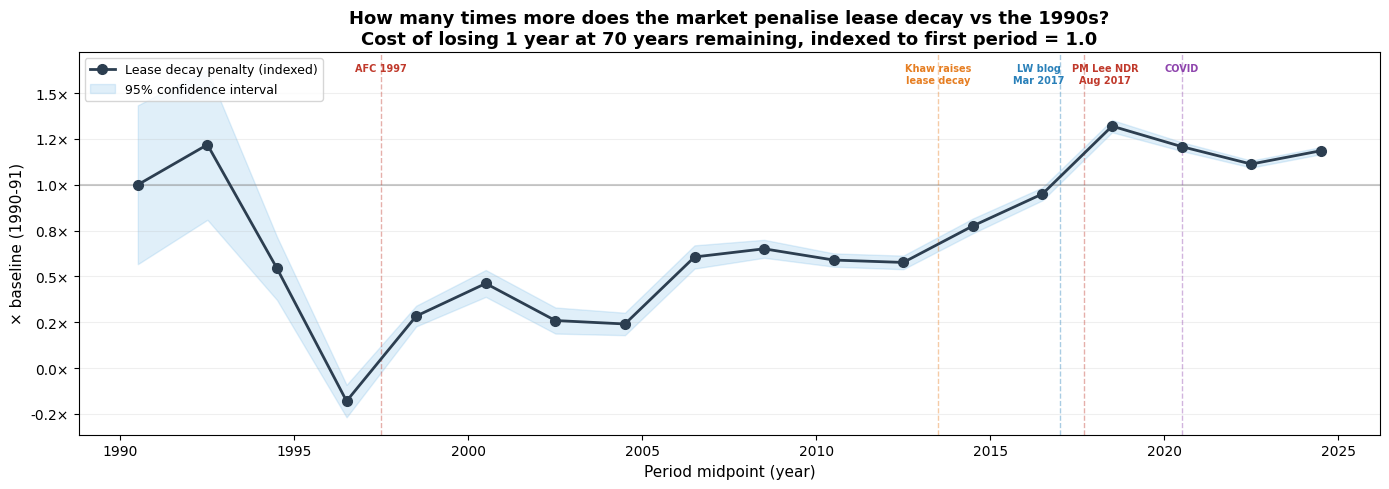

Saved to data/lease_decay_indexed.png


In [6]:
## Indexed chart: how many times more expensive is lease decay vs the 1990s?

baseline_pct = res['cost_pct'].iloc[0]
res['cost_indexed'] = res['cost_pct'] / baseline_pct
res['se_indexed'] = res['se_pct'] / abs(baseline_pct)

fig, ax = plt.subplots(figsize=(14, 5))

line, = ax.plot(res['midpoint'], res['cost_indexed'], 'o-', color='#2c3e50',
        linewidth=2, markersize=7, zorder=3, label='Lease decay penalty (indexed)')
band = ax.fill_between(res['midpoint'],
                res['cost_indexed'] - 1.96 * res['se_indexed'],
                res['cost_indexed'] + 1.96 * res['se_indexed'],
                alpha=0.15, color='#3498db', label='95% confidence interval')
ax.axhline(y=1, color='gray', linestyle='-', alpha=0.4)

# Policy events
events = [
    (1997.5, 'AFC 1997', '#c0392b'),
    (2013.5, 'Khaw raises\nlease decay', '#e67e22'),
    (2017.0, "LW blog\nMar 2017", '#2980b9'),
    (2017.7, "PM Lee NDR\nAug 2017", '#c0392b'),
    (2020.5, 'COVID', '#8e44ad'),
]
anno_offsets = {
    'AFC 1997': (0, -8),
    'Khaw raises\nlease decay': (0, -8),
    "LW blog\nMar 2017": (-15, -8),
    "PM Lee NDR\nAug 2017": (15, -8),
    'COVID': (0, -8),
}
for year, label, color in events:
    ax.axvline(x=year, color=color, linestyle='--', alpha=0.4, linewidth=1)
    dx, dy = anno_offsets[label]
    ax.annotate(label, xy=(year, ax.get_ylim()[1]), xytext=(dx, dy),
                textcoords='offset points', ha='center', va='top',
                fontsize=7, color=color, fontweight='bold')

ax.set_xlabel('Period midpoint (year)', fontsize=11)
ax.set_ylabel(f'× baseline ({res["period"].iloc[0]})', fontsize=11)
ax.set_title('How many times more does the market penalise lease decay vs the 1990s?\n'
             'Cost of losing 1 year at 70 years remaining, indexed to first period = 1.0',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}×'))
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('data/lease_decay_indexed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/lease_decay_indexed.png')

## Lease variation over time

Before interpreting the trend, we should check whether the growing coefficient is partly an artifact of increasing variation in remaining lease. If early periods have very little lease variation, the coefficient is harder to estimate and may be attenuated.

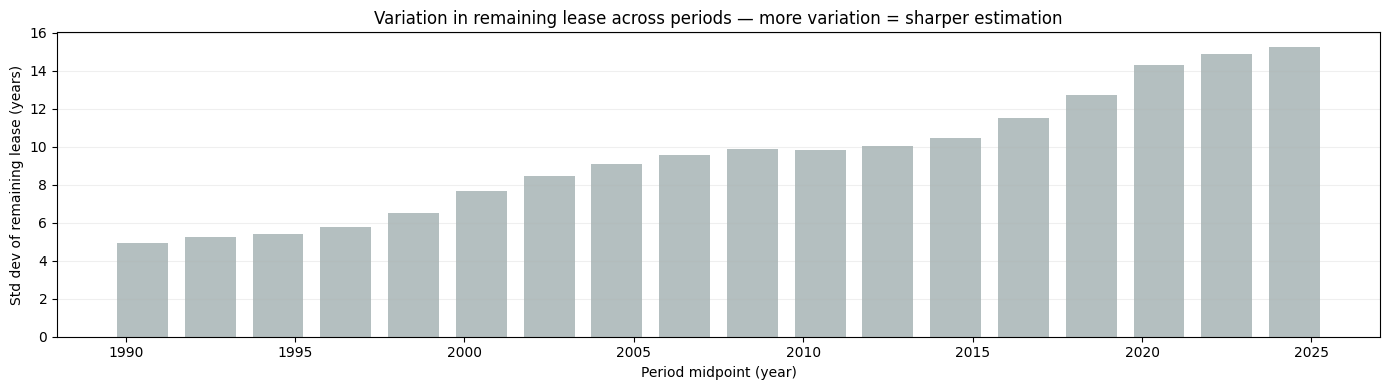

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(res['midpoint'], res['lease_sd'], width=1.5, color='#95a5a6', alpha=0.7)
ax.set_xlabel('Period midpoint (year)')
ax.set_ylabel('Std dev of remaining lease (years)')
ax.set_title('Variation in remaining lease across periods — more variation = sharper estimation')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## Interpretation

### The 1990s: the market priced lease decay early

In the earliest periods, losing a year of lease at 70 years remaining cost about 0.5–1.0% of the average flat price. Even when most flats had 85–95 years left and lease decay was a distant abstraction, buyers were pricing it in. The estimates are noisy (wide confidence intervals, SD of only 5–6 years in remaining lease), but the direction is clear.

### The 2000s boom wiped out lease awareness

Through the 2000s property boom, the lease penalty *halved*. At its lowest (2004-05), losing a year cost just 0.21% of the mean price — less than a quarter of what it cost in 1992-93. This wasn't a data problem: the SD of remaining lease was rising steadily (from 5 to 10 years), giving the model *more* variation to estimate from.

What happened? The PAP government had spent a decade reinforcing the "asset enhancement" narrative. PM Lee told the 2010 International Housing Conference that "provided Singapore continues to do well, our flats will maintain their value, and Singaporeans can enjoy an appreciating asset." Minister Mah Bow Tan in 2011 declared: "We are proud of the asset enhancement policy." As NUS sociologist Tan Ern Ser put it, "the years of experiencing asset enhancement and social upgradings have been deeply ingrained in the Singaporean psyche." The data bears this out: the market genuinely stopped penalising lease decay during the era of asset-enhancement messaging.

### 2013–2017: the government course-corrects, the market follows

Starting around 2014-15, the penalty climbs steeply. The policy timeline maps precisely onto the data:

- **2013**: Minister Khaw Boon Wan first broached diminishing resale values in Parliament — "how will its role as an asset be affected?" The penalty begins to rise in the 2014-15 window.
- **March 2017**: Minister Lawrence Wong's blog post warned that not all old flats will qualify for SERS. Media had reported buyers paying huge sums for ageing flats hoping for en bloc; Wong cautioned them to "be realistic."
- **August 2017**: PM Lee's NDR speech explicitly told Singaporeans that HDB flats are not appreciating assets and 99-year leases will expire. The sharpest single jump in the data is from 2016-17 (0.82%) to 2018-19 (1.13%) — a 38% increase in one window, spanning exactly this period.

Since 2018, the penalty has plateaued at roughly 1.0% of mean price — a new, higher equilibrium. As Ku Swee Yong (International Property Advisor) observed at the time: "One entire generation has already made their profits. Those who are left holding their flats today are disappointed that they did not downsize or sell out to extract their profits earlier."

### What the numbers mean in dollar terms

| Period | Cost of losing 1 year at 70 years remaining |
|---|---|
| 2004-05 (trough) | ~$500 |
| 2016-17 (pre-blog post) | ~$3,600 |
| 2018-19 (post-NDR speech) | ~$5,000 |
| 2024-25 (current) | ~$6,400 |

Most of the dollar increase (from $500 to $6,400) is driven by rising flat prices — the mean price tripled from $235K to $632K over that period. The normalised % chart strips out inflation and reveals the behavioural shift: the market roughly doubled its sensitivity to lease decay between the mid-2000s and the late 2010s.

### Corroboration

NUS Institute of Real Estate Studies director Sing Tien Foo independently found a "significant negative relationship between HDB resale prices and age" using 1997–2017 transaction data, estimating discounts of 8.3% for 40-50 year old flats and 9.5% for 50-60 year old flats (after controlling for unit area, floor height, and distance to schools and MRT). Our approach differs (we track the marginal cost of one year, not age-bracket discounts), but both point to the same conclusion: the market prices lease decay, and it prices it more aggressively now than it used to.

### Could this be a data artifact?

Lease variation (SD) tripled from 5 years in 1990 to 15 years in 2024, which mechanically allows sharper estimation. But the timing doesn't match: the SD grew *steadily* over 35 years, while the penalty jump was *concentrated* in 2014–2019. If this were purely a statistical artifact, the penalty should have risen gradually with SD. Instead, it shows a clear structural break — consistent with a real change in market behaviour triggered by policy messaging.

### The 1996-97 outlier

The AFC period is the only window where the penalty briefly reverses (losing a year slightly *increases* price). This is noise in a collapsing market — transaction volumes spiked as panicked sellers flooded the market, and the usual pricing relationships broke down.

## Same-age comparison: how much less does a 60-year-lease flat sell for vs a 90-year-lease flat?

A more intuitive way to see the shift: take two identical flats — same town, same type, same size, same floor — but one has 90 years of lease left and the other has 60 years. How much less does the older flat sell for? And how has that gap changed over time?

From each period's regression:

> gap = β₁ × (90 − 60) + β₂ × (90² − 60²) = 30β₁ + 4500β₂

In [8]:
# Price gap: 90 years remaining vs 60 years remaining, all else equal
# gap = 30*beta1 + (90^2 - 60^2)*beta2 = 30*beta1 + 4500*beta2

res['gap_90v60'] = 30 * res['coef_lease'] + 4500 * res['coef_lease_sq']
res['gap_90v60_pct'] = (res['gap_90v60'] / res['mean_price']) * 100

# Also compute 90 vs 70 and 90 vs 50
res['gap_90v70'] = 20 * res['coef_lease'] + (90**2 - 70**2) * res['coef_lease_sq']
res['gap_90v50'] = 40 * res['coef_lease'] + (90**2 - 50**2) * res['coef_lease_sq']

print('Price gap: how much MORE does a 90-year-lease flat sell for vs a shorter-lease flat?')
print('(Same town, flat type, size, floor — only lease differs)\n')

gap_fmt = res[['period', 'mean_price', 'gap_90v70', 'gap_90v60', 'gap_90v50']].copy()
gap_fmt.columns = ['Period', 'Mean Price', '90 vs 70yr', '90 vs 60yr', '90 vs 50yr']
gap_fmt['Mean Price'] = gap_fmt['Mean Price'].apply(lambda x: f'${x:,.0f}')
gap_fmt['90 vs 70yr'] = gap_fmt['90 vs 70yr'].apply(lambda x: f'${x:,.0f}')
gap_fmt['90 vs 60yr'] = gap_fmt['90 vs 60yr'].apply(lambda x: f'${x:,.0f}')
gap_fmt['90 vs 50yr'] = gap_fmt['90 vs 50yr'].apply(lambda x: f'${x:,.0f}')
print(gap_fmt.to_string(index=False))

Price gap: how much MORE does a 90-year-lease flat sell for vs a shorter-lease flat?
(Same town, flat type, size, floor — only lease differs)

 Period Mean Price 90 vs 70yr 90 vs 60yr 90 vs 50yr
1990-91    $70,876    $14,139    $19,741    $24,365
1992-93   $111,273    $21,608    $33,685    $46,611
1994-95   $192,708    $17,600    $26,713    $36,035
1996-97   $293,063    $15,040     $4,487   $-18,114
1998-99   $254,806    $24,066    $27,367    $24,846
2000-01   $250,444    $35,315    $41,391    $39,745
2002-03   $233,279    $35,498    $34,428    $20,812
2004-05   $234,659    $36,974    $35,012    $19,419
2006-07   $249,071    $49,840    $56,841    $51,895
2008-09   $328,107    $56,838    $70,149    $73,387
2010-11   $397,661    $68,056    $81,256    $80,570
2012-13   $467,616    $77,017    $92,502    $92,637
2014-15   $438,514    $84,246   $107,025   $116,909
2016-17   $441,436    $83,629   $116,788   $144,177
2018-19   $436,645    $93,027   $144,051   $198,081
2020-21   $485,074   $102

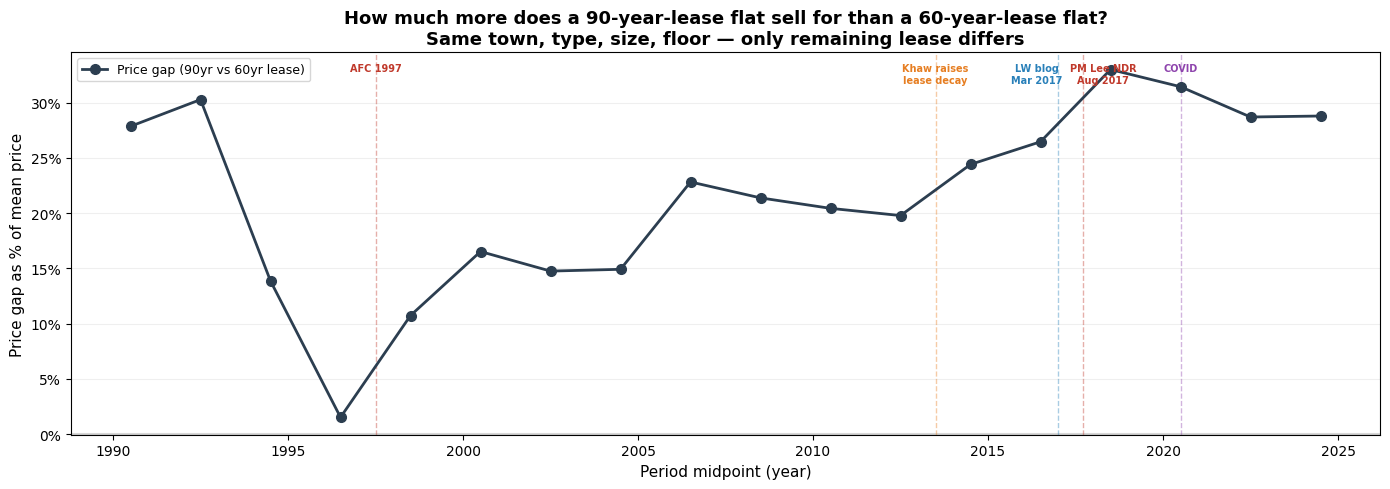

In [9]:
# Chart: 90 vs 60 year gap as % of mean price over time
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(res['midpoint'], res['gap_90v60_pct'], 'o-', color='#2c3e50',
        linewidth=2, markersize=7, zorder=3, label='Price gap (90yr vs 60yr lease)')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Policy events
events = [
    (1997.5, 'AFC 1997', '#c0392b'),
    (2013.5, 'Khaw raises\nlease decay', '#e67e22'),
    (2017.0, "LW blog\nMar 2017", '#2980b9'),
    (2017.7, "PM Lee NDR\nAug 2017", '#c0392b'),
    (2020.5, 'COVID', '#8e44ad'),
]
anno_offsets = {
    'AFC 1997': (0, -8),
    'Khaw raises\nlease decay': (0, -8),
    "LW blog\nMar 2017": (-15, -8),
    "PM Lee NDR\nAug 2017": (15, -8),
    'COVID': (0, -8),
}
for year, label, color in events:
    ax.axvline(x=year, color=color, linestyle='--', alpha=0.4, linewidth=1)
    dx, dy = anno_offsets[label]
    ax.annotate(label, xy=(year, ax.get_ylim()[1]), xytext=(dx, dy),
                textcoords='offset points', ha='center', va='top',
                fontsize=7, color=color, fontweight='bold')

ax.set_xlabel('Period midpoint (year)', fontsize=11)
ax.set_ylabel('Price gap as % of mean price', fontsize=11)
ax.set_title('How much more does a 90-year-lease flat sell for than a 60-year-lease flat?\n'
             'Same town, type, size, floor — only remaining lease differs',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

**The table above** answers: if you took two identical flats — same town, same flat type, same size, same floor — but one has 90 years of lease left and the other has fewer, how much more does the 90-year flat sell for? The three columns show this gap for 70, 60, and 50 years of remaining lease. Each row is a different 2-year period.

**The chart above** plots the 90-vs-60 gap as a percentage of the mean flat price. Higher means the market penalises the older flat more.

---

## What the same-age comparison reveals

### The 90-vs-50 gap has exploded

A flat with 50 years of lease left now sells for **$257,000 less** than an identical flat with 90 years left. In 2004-05, that same gap was just **$19,000**.

In percentage terms: the 90-vs-50 discount went from **8% to 41%** of the mean flat price. The market has become five times more punishing toward flats approaching the tail end of their lease.

### "Slightly old" flats were always penalised — "really old" is where the shift happened

The 90-vs-70 gap (a flat that's lost 20 years of lease) has been remarkably stable:

| Period | 90 vs 70yr gap | As % of mean price |
|---|---|---|
| 1990-91 | $14,000 | 20% |
| 2004-05 | $37,000 | 16% |
| 2018-19 | $93,000 | 21% |
| 2024-25 | $114,000 | 18% |

The percentage barely moved — 15–21% across 35 years. The market has always discounted "a bit old" by roughly the same amount. This is the predictable, linear part of lease decay.

The 90-vs-50 gap (a flat that's lost 40 years of lease) tells a completely different story:

| Period | 90 vs 50yr gap | As % of mean price |
|---|---|---|
| 1990-91 | $24,000 | 34% |
| 2004-05 | $19,000 | **8%** |
| 2018-19 | $198,000 | **45%** |
| 2024-25 | $257,000 | **41%** |

The discount for "really old" flats collapsed to 8% during the asset-enhancement boom, then surged back to 41% after the government's course correction. The 2004-05 market was essentially saying: "50 years left vs 90 years left? Who cares." The 2024-25 market says: "50 years left costs you two-fifths of the flat's value."

### The market learned non-linear pricing

The key shift isn't that lease decay matters more overall — it's that the market learned to price the **acceleration** at shorter leases. In the 2000s, the quadratic term was large and positive, flattening the curve at shorter leases — the market barely distinguished between 60 and 50 years. Today, the quadratic term is negative, meaning each year lost hurts *more* as the lease gets shorter. This matches what leasehold valuation theory predicts.

### The penalty adjusted once and stabilised

In 2018, the fear was that lease decay pricing would spiral out of control. Instead, the 90-vs-50 gap has held steady at ~41% since 2018 — the market found its new equilibrium. The government's intervention triggered a correction, not a panic.

But the dollar cost keeps rising because flat prices keep rising. A 41% gap applied to a $632,000 mean price is $257,000. The same 41% applied to $437,000 (2018-19) was $198,000. Even with a stable percentage penalty, the absolute cost of owning an older flat grows with every price cycle — which means the conversation about lease decay is not going away even though the market's *attitude* toward it has stopped changing.